<>:100: SyntaxWarning: invalid escape sequence '\l'
<>:100: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_58/1323954189.py:100: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_ylabel('Surprisal Score ($-\log P$)')


Loading datasets...

--- Analyzing H1: Original vs Caroline ---
Accuracy on Original Text: 58.33%
Accuracy on Caroline Text: 43.14%
H1 Plot saved as Vector PDF: /kaggle/working/results/h1_accuracy_drop.pdf


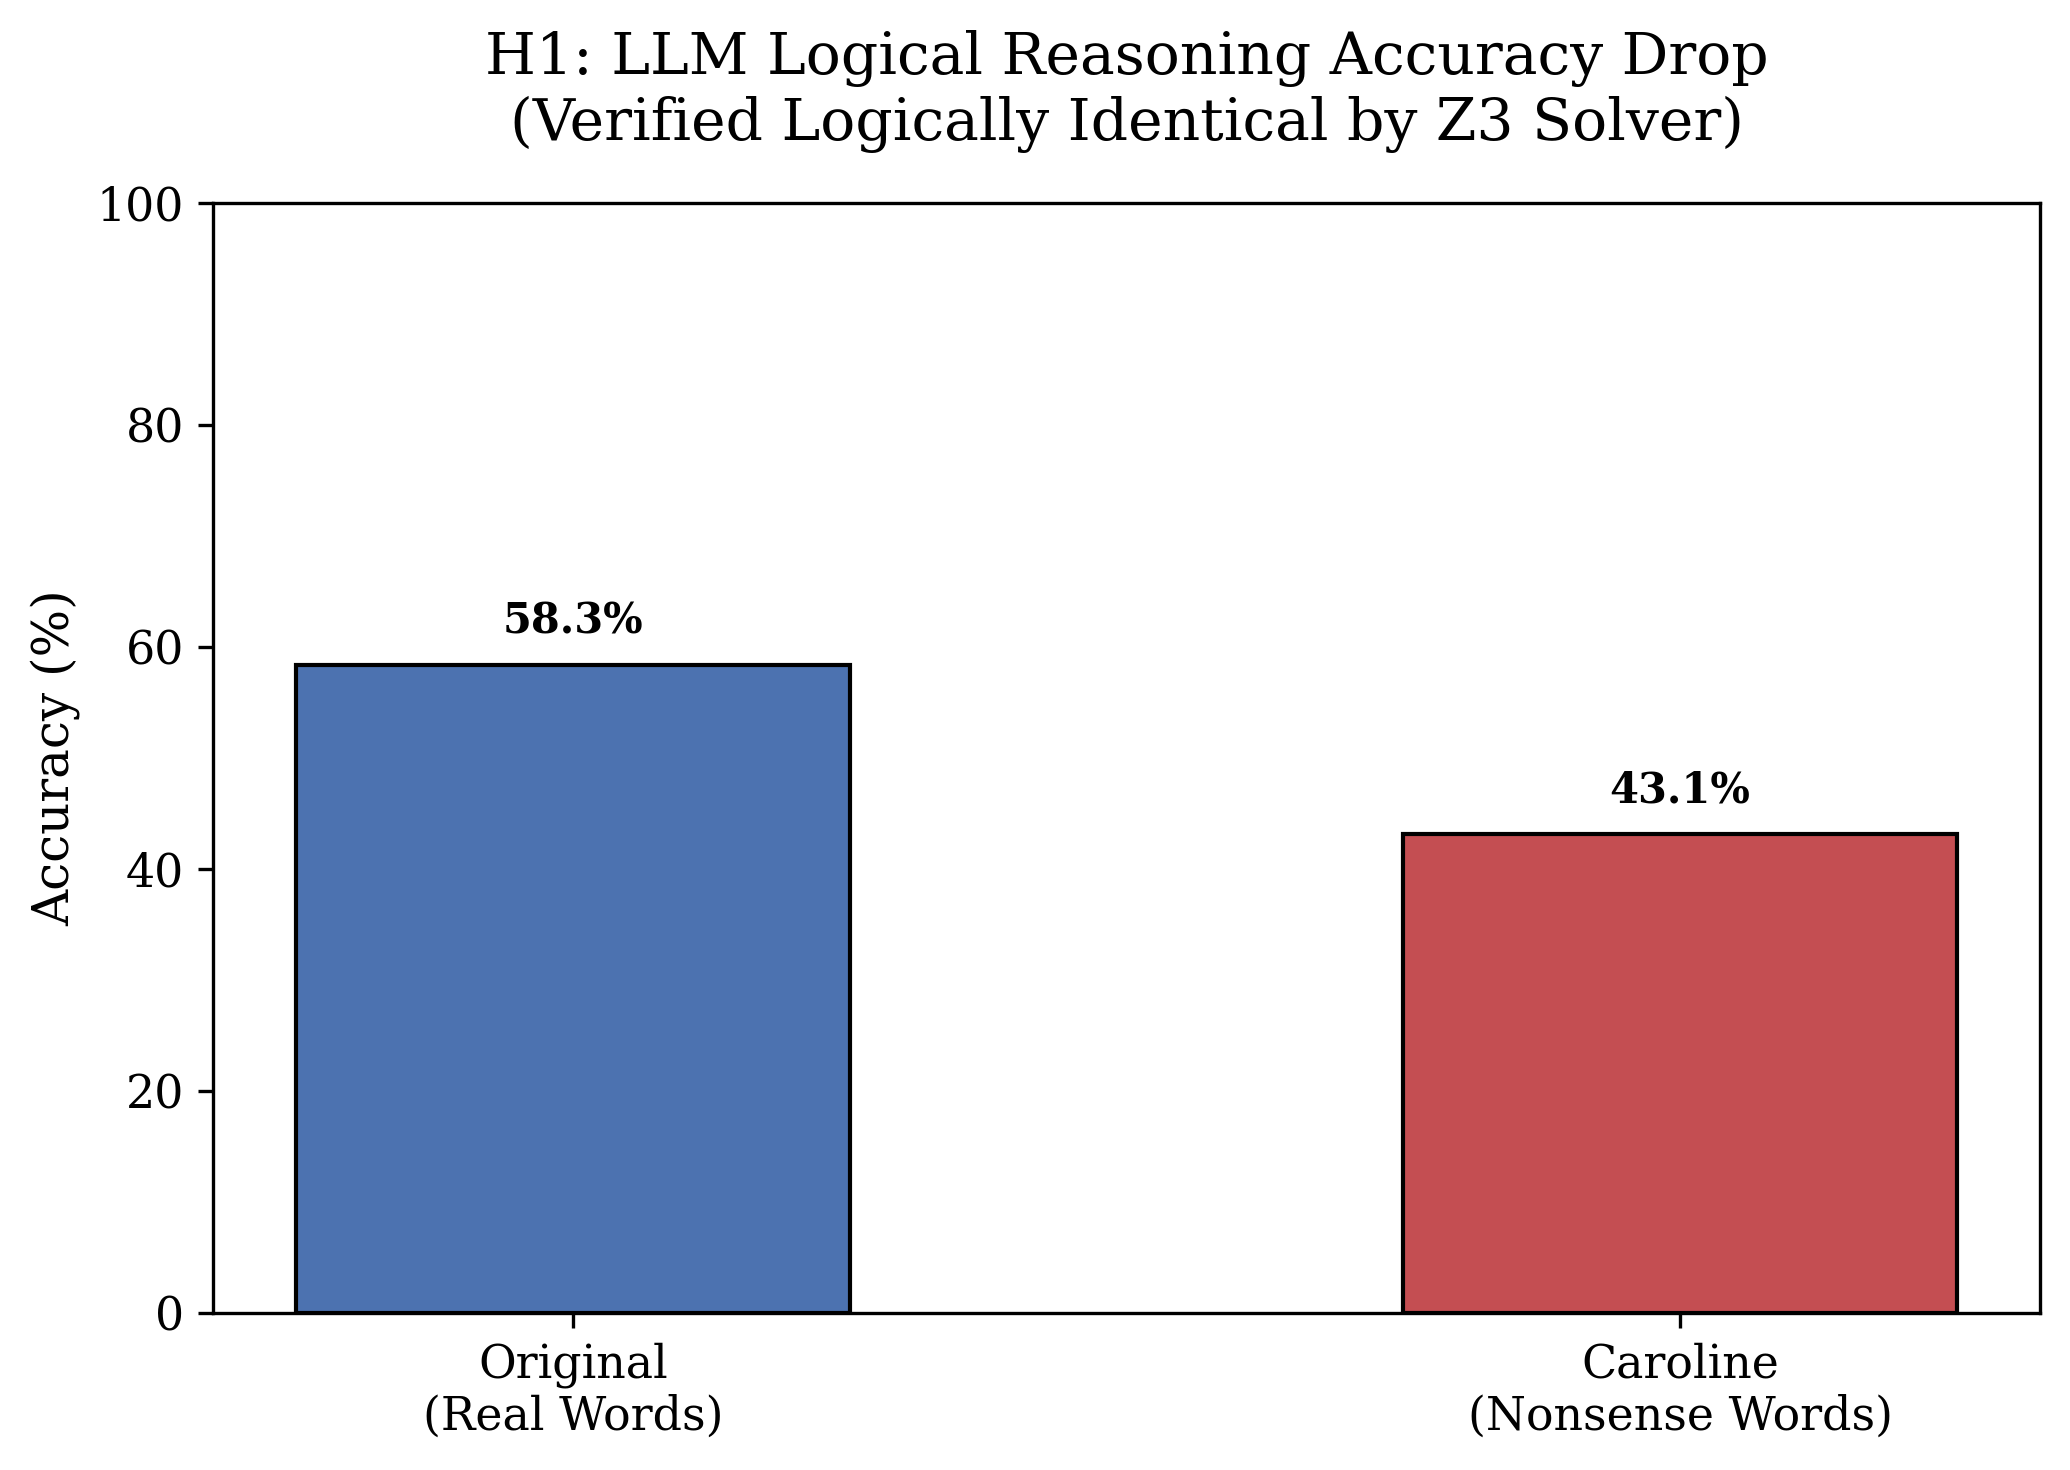


--- Analyzing H2: Quantifier Scoping Surprisal ---
H2 Plot saved as Vector PDF: /kaggle/working/results/h2_surprisal_inconsistency.pdf


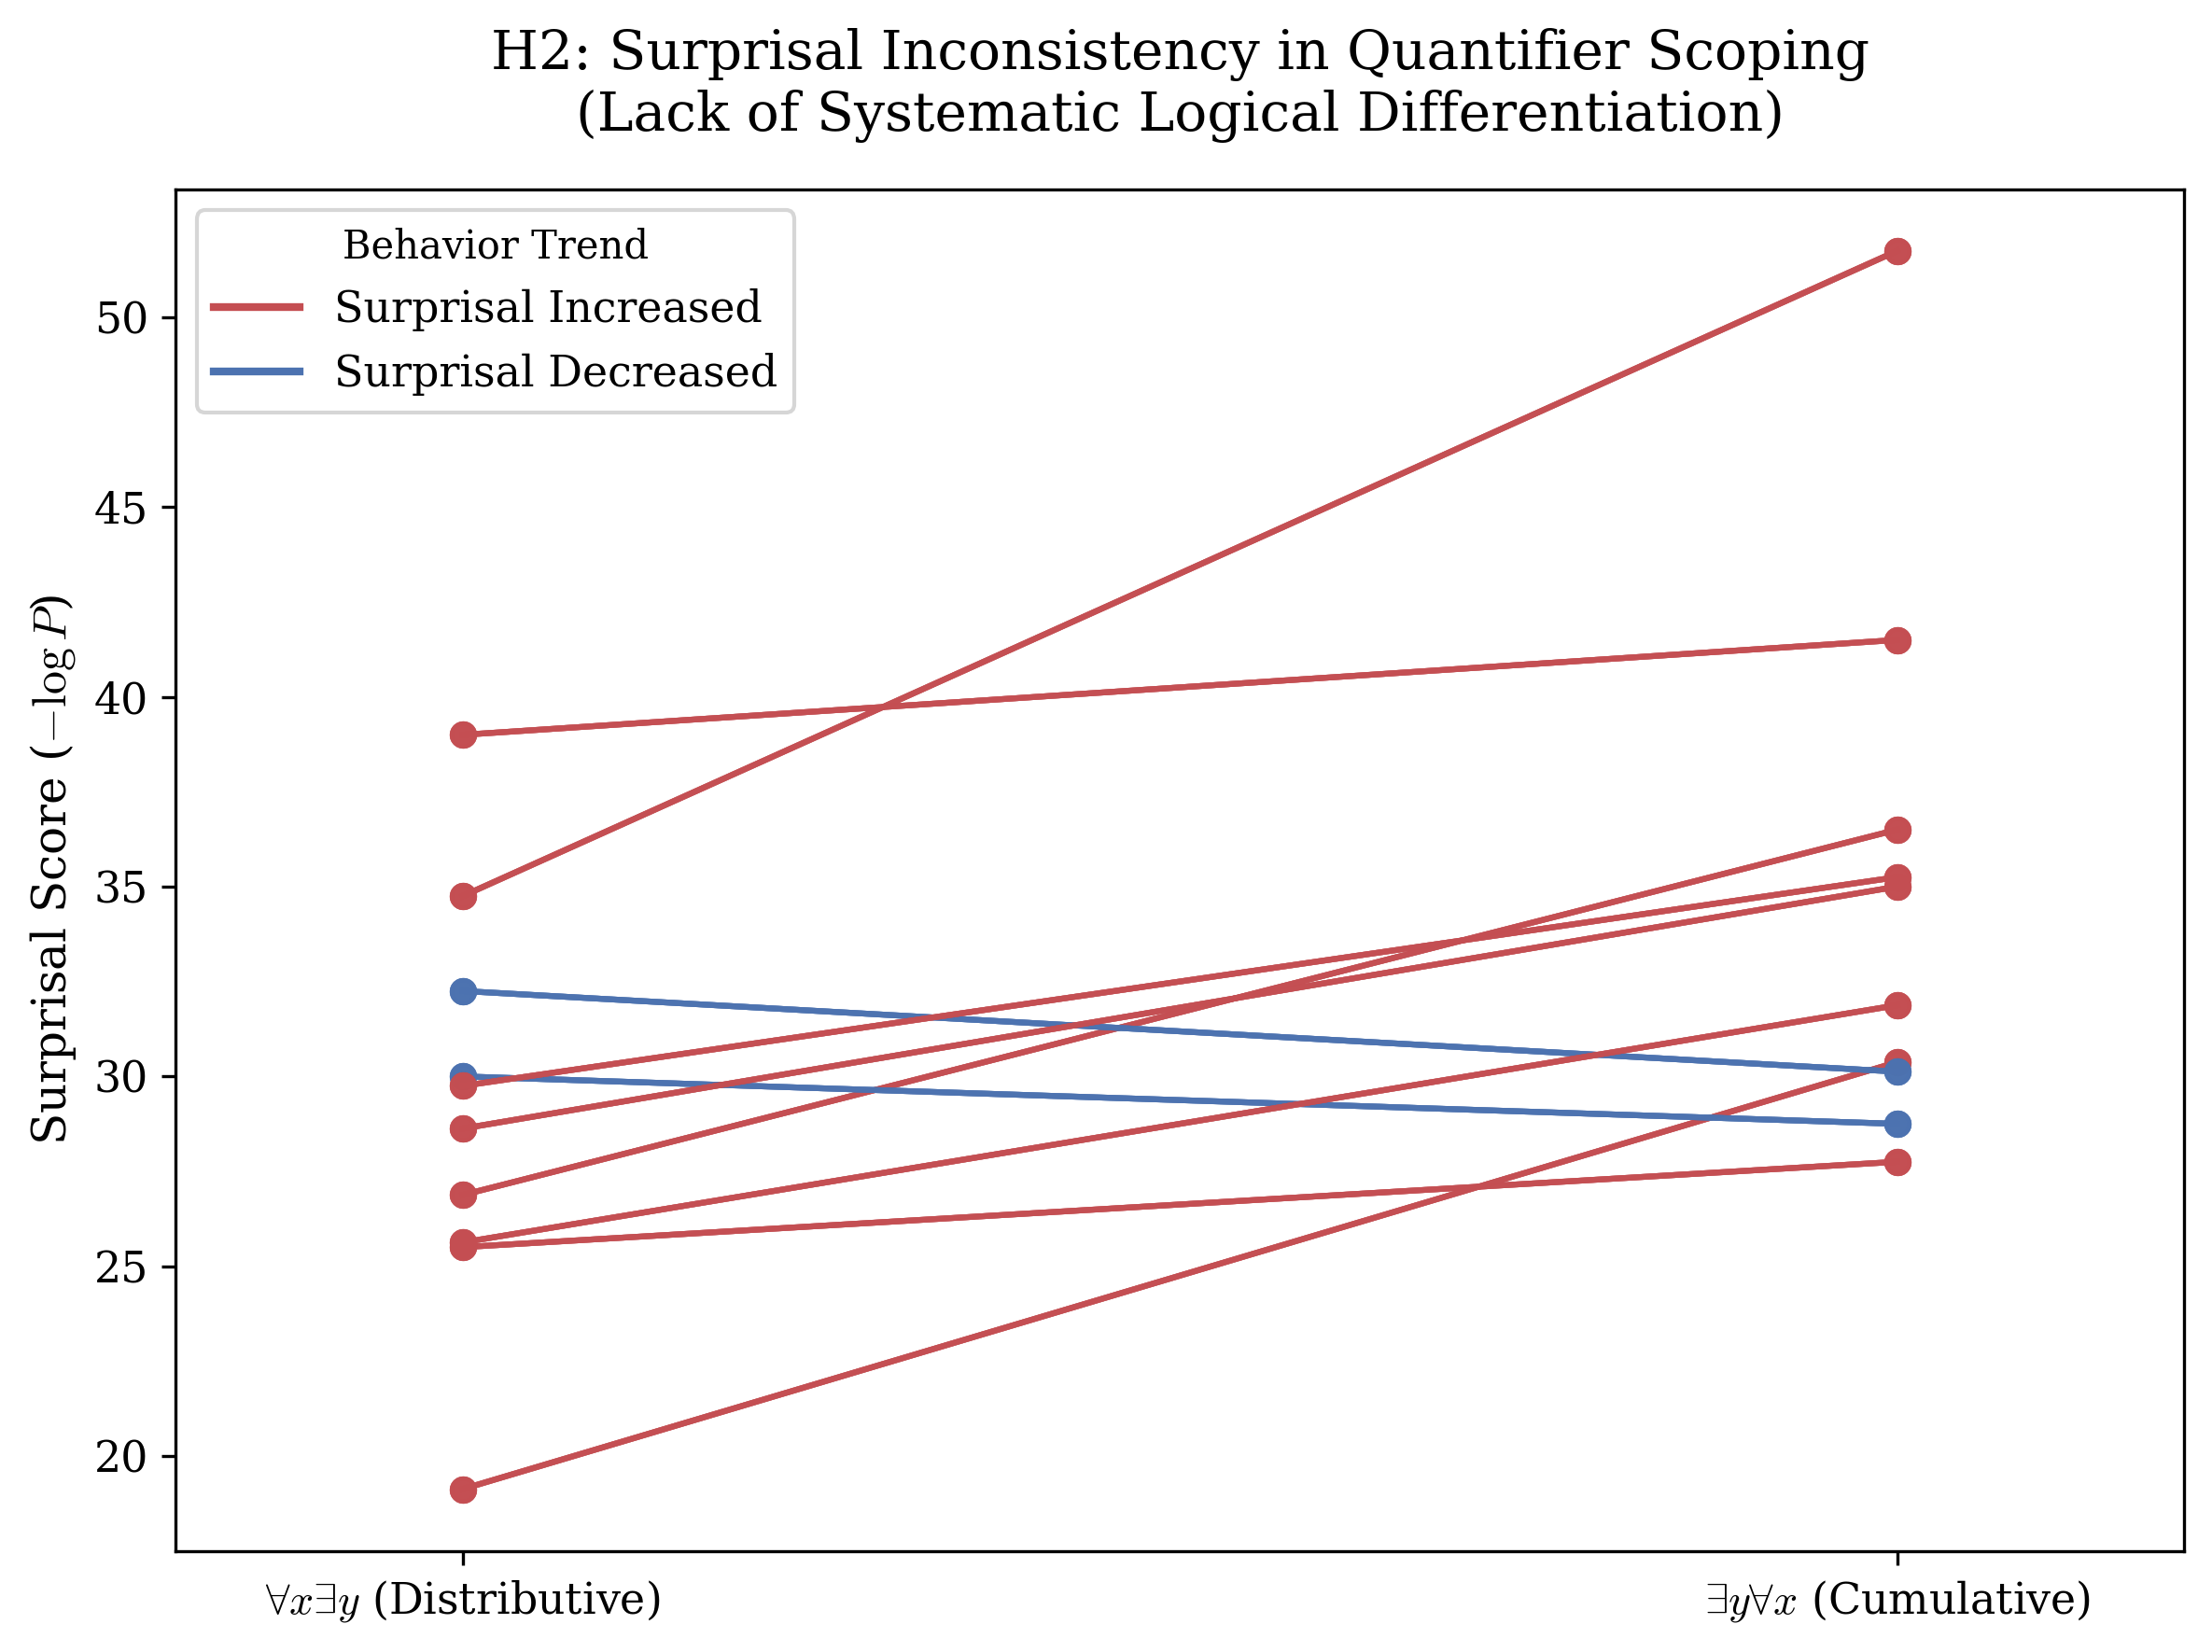


All tasks completed successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# =========================================================
# Academic Plotting Configuration (LaTeX Fonts & Style)
# =========================================================
plt.rcParams.update({
    "font.family": "serif",        # Use serif fonts (like Times/LaTeX)
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "text.usetex": False,          # Set to True if you have a full LaTeX engine installed, False is safer in Kaggle
    "mathtext.fontset": "cm",      # Computer modern math font
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 300              # High resolution for display
})

# Create folder for saving plots
os.makedirs('/kaggle/working/results', exist_ok=True)

# Define file paths (UPDATE THESE if your dataset names are different)
h1_file = '/kaggle/input/datasets/alirezaebrahimi/folio-h1-llm-answers/llm_answers_h1.csv'  
h2_file = '/kaggle/input/datasets/alirezaebrahimi/folio-h2-surprisal-data/surprisal_results_h2.csv' 

print("Loading datasets...")
df_h1 = pd.read_csv(h1_file)
df_h2 = pd.read_csv(h2_file)

# =========================================================
# ANALYSIS 1: Hypothesis H1 (Accuracy Drop with Caroline Filter)
# =========================================================
print("\n--- Analyzing H1: Original vs Caroline ---")

# Clean strings just in case
df_h1['label'] = df_h1['label'].astype(str).str.strip().str.capitalize()
df_h1['llm_answer_original'] = df_h1['llm_answer_original'].astype(str).str.strip().str.capitalize()
df_h1['llm_answer_caroline'] = df_h1['llm_answer_caroline'].astype(str).str.strip().str.capitalize()

# Calculate Accuracy
acc_original = (df_h1['label'] == df_h1['llm_answer_original']).mean() * 100
acc_caroline = (df_h1['label'] == df_h1['llm_answer_caroline']).mean() * 100

print(f"Accuracy on Original Text: {acc_original:.2f}%")
print(f"Accuracy on Caroline Text: {acc_caroline:.2f}%")

# Plot 1: Bar Chart
fig1, ax1 = plt.subplots(figsize=(7, 5))
bars = ax1.bar(['Original\n(Real Words)', 'Caroline\n(Nonsense Words)'], 
               [acc_original, acc_caroline], 
               color=['#4C72B0', '#C44E52'], edgecolor='black', width=0.5)

ax1.set_title('H1: LLM Logical Reasoning Accuracy Drop\n(Verified Logically Identical by Z3 Solver)', pad=15)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 100)

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

# Save as Vector PDF
h1_plot_path_pdf = '/kaggle/working/results/h1_accuracy_drop.pdf'
plt.savefig(h1_plot_path_pdf, format='pdf', bbox_inches='tight')
print(f"H1 Plot saved as Vector PDF: {h1_plot_path_pdf}")
plt.show()

# =========================================================
# ANALYSIS 2: Hypothesis H2 (Quantifier Scoping Surprisal)
# =========================================================
print("\n--- Analyzing H2: Quantifier Scoping Surprisal ---")

# Plot 2: Paired Slopegraph
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_pairs = df_h2['pair_id'].unique()

# Plot lines connecting Distributive and Cumulative for each pair
for pid in unique_pairs:
    subset = df_h2[df_h2['pair_id'] == pid]
    if len(subset) == 2:
        dist_val = subset[subset['scope_type'].str.contains('Distributive')]['surprisal_score'].values[0]
        cum_val = subset[subset['scope_type'].str.contains('Cumulative')]['surprisal_score'].values[0]
        
        # Color red if surprisal goes UP, blue if it goes DOWN
        line_color = '#C44E52' if cum_val > dist_val else '#4C72B0'
        
        ax2.plot([1, 2], [dist_val, cum_val], marker='o', color=line_color, alpha=0.6, linewidth=1.5)

ax2.set_xticks([1, 2])
ax2.set_xticklabels([r'$\forall x \exists y$ (Distributive)', r'$\exists y \forall x$ (Cumulative)'])
ax2.set_title('H2: Surprisal Inconsistency in Quantifier Scoping\n(Lack of Systematic Logical Differentiation)', pad=15)
ax2.set_ylabel('Surprisal Score ($-\log P$)')
ax2.set_xlim(0.8, 2.2)

# Custom legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='#C44E52', lw=2),
                Line2D([0], [0], color='#4C72B0', lw=2)]
ax2.legend(custom_lines, ['Surprisal Increased', 'Surprisal Decreased'], title='Behavior Trend', loc='best')

plt.tight_layout()

# Save as Vector PDF
h2_plot_path_pdf = '/kaggle/working/results/h2_surprisal_inconsistency.pdf'
plt.savefig(h2_plot_path_pdf, format='pdf', bbox_inches='tight')
print(f"H2 Plot saved as Vector PDF: {h2_plot_path_pdf}")
plt.show()

print("\nAll tasks completed successfully!")